# Modelado y Evaluación de Clasificadores

Notebook de la etapa **3** del pipeline: entrenamiento, evaluación y exportación de los modelos de detección de cyberbullying en texto.

Se entrenan **7 clasificadores** con un pipeline `TfidfVectorizer + clasificador` (Regresión Logística, Multinomial Naive Bayes, SVM lineal, Random Forest, Gradient Boosting, XGBoost y Red Neuronal), se evalúan sobre el test (precisión, recall, F1 y accuracy) y se exportan a `../models/*.pkl` junto con la tabla de resultados `../data/models_results.csv`. La UI (Streamlit) recomienda dinámicamente el modelo con mayor F1.

Los resultados documentados en este notebook provienen del entrenamiento del pipeline con la configuración vigente (partición estratificada 80/20, validación cruzada cv=5 sobre F1 y umbral de decisión 0.5). Los artefactos en `../models/` y `data/output/models_results.csv` reflejan esa corrida.


In [2]:
!pip install --quiet xgboost tqdm

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
# Saving objects
import joblib
# Data handlig & Exploratory Data Analysis (EDA):
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
# Metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier

## Carga del dataset

Se carga el dataset intermedio generado por la etapa 00 (`../data/processed/cyberbullying_preprocessed.csv`, columnas `text`, `label`, `text_preprocessed`). El conteo impreso refleja el número de mensajes listos para modelar.


In [4]:
df = pd.read_csv('../data/processed/cyberbullying_preprocessed.csv')
# data = [tuple(x) for x in df.values]
print('Número de datos cargados: {num}'.format(num=len(df)))

Número de datos cargados: 80974


## Separación de características y etiqueta

Se separa el texto preprocesado (`X`) de la variable objetivo (`y`): `X` contiene los mensajes y `y` las etiquetas de clase. El `head()` permite inspeccionar el alineamiento entre ambos.


In [5]:

X = df['text_preprocessed']
y = df['label'] 

pd.DataFrame({'X': X, 'y': y}).head()

,X,y
0,word food crapilicious,0
1,white,0
2,classy whore red velvet cupcake,0
3,meh thank head not_concerned angry dude twitter,0
4,isis account pretend kurdish account like isla...,0


# Dividimos los datos en dos conjuntos: entrenamiento y test
- El conjunto de entrenamiento se utiliza para ajustar el modelo
- El conjunto de test se utiliza para evaluar el modelo
- La proporción de los datos que se utilizan para el test es del 20%
- La semilla aleatoria se fija en 1 para que los resultados sean reproducibles
- Se imprime el número de mensajes que se utilizarán para el entrenamiento y el test


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

print('Número de Mensajes para el entrenamiento: {num}'.format(num=X_train.shape[0]))
print('Número de Mensajes para el test: {num}'.format(num=X_test.shape[0]))

pd.DataFrame({
    'X_train': X_train[:5].tolist(),
    'y_train': y_train[:5].tolist(),
    'X_test': X_test[:5].tolist(),
    'y_test': y_test[:5].tolist()
}).head()

Número de Mensajes para el entrenamiento: 64779
Número de Mensajes para el test: 16195


,X_train,y_train,X_test,y_test
0,swag today,0,hate people people think okay,0
1,cock theory well mess upgrade blog go perfectly,0,not_messiah salvege religion moses christ coup...,1
2,lady cook storm,0,shout name shame drama school teacher bully ab...,1
3,problematic white gay rape trend rape joke lot,1,help help love marilyn manson,0
4,antis stop treat block trophy soon feminist st...,1,read get away keyboard bit bring stuff car wee...,1


# Modelos de Machine Learning para entrenar.
- Regresión Logística
- Multinomial Naive Bayes
- Support Vector Machine (Linear Kernel)
- Random Forest
- Gradient Boosting
- XGBoost
- Neural Network


In [7]:
from sklearn.metrics import classification_report, accuracy_score


def evaluate(actual, predicted, model_name):
    """Metricas sobre la clase positiva (bullying) para un modelo."""
    report = classification_report(actual, predicted, output_dict=True)
    positive = report['1']
    return {
        'Model': model_name,
        'Precision': positive['precision'],
        'Recall': positive['recall'],
        'F1': positive['f1-score'],
        'Accuracy': accuracy_score(actual, predicted),
    }


SEED = 42  # reproducibilidad

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine (Linear Kernel)': SVC(kernel='linear', probability=True),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'XGBoost': XGBClassifier(n_jobs=-1, random_state=SEED, eval_metric='logloss'),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(150, 100, 50), activation='relu',
                                    solver='adam', max_iter=300, random_state=SEED, verbose=True, early_stopping=True),
}


In [8]:
import os
from tqdm.auto import tqdm

retrain = False  # False: reutiliza resultados guardados; True: fuerza re-entrenar.
results_path = '../data/output/models_results.csv'


def train(name, model):
    """Construye y entrena el pipeline sobre el set de entrenamiento."""
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('classify', model),
    ])
    pipeline.fit(X_train, y_train)
    return pipeline


def save(name, pipeline):
    """Persiste el pipeline entrenado a disco (.pkl)."""
    path = f'../models/{name.lower().replace(" ", "_")}.pkl'
    joblib.dump(pipeline, path)


def report(results):
    """Arma la tabla de resultados y la guarda como CSV."""
    models_results = pd.DataFrame(results)
    models_results.to_csv(results_path, index=False)
    return models_results


if not retrain and os.path.exists(results_path):
    models_results = pd.read_csv(results_path)
    print('Resultados ya guardados. Cargados desde:', results_path)
else:
    results = []
    for name, model in tqdm(models.items(), desc='Entrenando modelos', unit='modelo'):
        pipeline = train(name, model)
        save(name, pipeline)
        results.append(evaluate(y_test, pipeline.predict(X_test), name))
    models_results = report(results)
    print('Modelos entrenados y guardados en:', results_path)



Resultados ya guardados. Cargados desde: ../data/output/models_results.csv


## Validación cruzada (cv=5)

Se estima la robustez de cada modelo con validación cruzada de 5 pliegues sobre el **pipeline completo** (TfidfVectorizer + clasificador), usando la partición de entrenamiento para no contaminar la evaluación final del test. La métrica es la F1 media, complementando la evaluación puntual sobre el test.

Dado el costo de correr cv=5 sobre ~65k mensajes, la validación se restringe a los **3 mejores modelos según F1** de la evaluación sobre test (`TOP_CV = 3`), que en este experimento son Random Forest, SVM lineal y Regresión Logística.


In [ ]:
from sklearn.model_selection import cross_val_score

# 1) CV completa sobre todos los datos de entrenamiento.
X_cv, y_cv = X_train, y_train

# 2) Solo se examinan los 3 mejores modelos segun F1 del entrenamiento.
TOP_CV = 3
finalists_names = models_results.sort_values(by='F1', ascending=False).head(TOP_CV)['Model']
finalists = {name: models[name] for name in finalists_names if name in models}

cv_rows = []
for model_name, model in finalists.items():
    pipeline_cv = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('classify', model)
    ])
    cv_scores = cross_val_score(pipeline_cv, X_cv, y_cv, cv=5, scoring='f1',
                               n_jobs=-1)
    cv_rows.append({'Model': model_name, 'F1_media': cv_scores.mean(), 'F1_std': cv_scores.std()})

cv_results = (pd.DataFrame(cv_rows)
              .sort_values('F1_media', ascending=False)
              .reset_index(drop=True))
cv_results.style.format({'F1_media': '{:.4f}', 'F1_std': '{:.4f}'}).bar(
    subset=['F1_media'], color='#5e81ac'
)


## Métricas de evaluación

Las predicciones de cada modelo se evalúan comparando el valor real con el valor predicho de cada mensaje. Las cuatro combinaciones posibles entre ambas etiquetas constituyen la **matriz de confusión**:

- **TP (Verdadero Positivo)**: el valor real es positivo (acoso) y el modelo predice positivo.
- **TN (Verdadero Negativo)**: el valor real es negativo (no acoso) y el modelo predice negativo.
- **FP (Falso Positivo)**: el valor real es negativo, pero el modelo predice positivo.
- **FN (Falso Negativo)**: el valor real es positivo, pero el modelo predice negativo.

Sobre esta matriz se cuantifican las métricas de rendimiento utilizadas: Accuracy, Precision, Recall y F1-Score.

**Accuracy (Exactitud)**: proporción global de predicciones correctas sobre el total de casos evaluados. Da una visión general, pero no distingue entre los tipos de errores cometidos.

$$ \mathrm{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

**Precision (Precisión)**: proporción de casos positivos correctamente identificados frente al total de predicciones clasificadas como positivas. Una alta precisión indica baja tasa de falsos positivos: minimiza etiquetar incorrectamente un mensaje neutral como acoso.

$$ \mathrm{Precision} = \frac{TP}{TP + FP} $$

**Recall (Sensibilidad)**: capacidad de identificar la totalidad de los casos positivos reales. Un valor alto indica baja tasa de falsos negativos: el modelo detecta la mayor parte de las conductas de acoso sin omitirlas.

$$ \mathrm{Recall} = \frac{TP}{TP + FN} $$

**F1-Score**: media armónica entre Precision y Recall. Penaliza los valores extremos y busca un equilibrio entre la exactitud de las predicciones positivas y los errores cometidos.

$$ \mathrm{F1} = \frac{2 \times (\mathrm{Precision} \times \mathrm{Recall})}{\mathrm{Precision} + \mathrm{Recall}} $$

No existe una métrica perfecta o universal; la selección depende del contexto. Dado el **desbalance de clases** de este dataset (≈ 61 % frente a ≈ 39 %), el **Accuracy resultaría engañoso** y se usa el **F1-Score como métrica de referencia**, complementado por Precision y Recall para interpretar el tipo de errores de cada modelo.

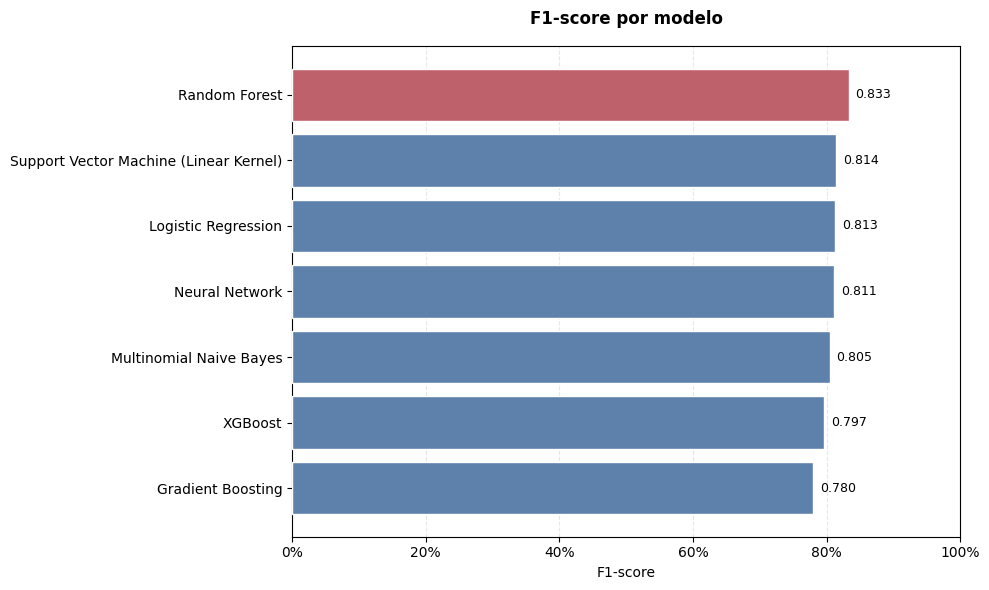

,Model,Precision,Recall,F1,Accuracy
0,Random Forest,0.836,0.829,0.833,0.797
1,Support Vector Machine (Linear Kernel),0.854,0.777,0.814,0.783
2,Logistic Regression,0.847,0.781,0.813,0.780
3,Neural Network,0.874,0.757,0.811,0.785
4,Multinomial Naive Bayes,0.736,0.888,0.805,0.737
5,XGBoost,0.905,0.712,0.797,0.779
6,Gradient Boosting,0.911,0.682,0.780,0.765


In [11]:
import matplotlib.ticker as mticker

models_results.sort_values(by=['F1'], ascending=False, inplace=True, ignore_index=True)

df_plot = models_results.sort_values('F1', ascending=True).reset_index(drop=True)
colors = ['#bf616a' if i == len(df_plot) - 1 else '#5e81ac' for i in range(len(df_plot))]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_plot['Model'], df_plot['F1'], color=colors, edgecolor='white', zorder=3)
ax.set_title('F1-score por modelo', fontweight='bold', pad=16)
ax.set_xlabel('F1-score')
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
for i, value in enumerate(df_plot['F1']):
    ax.text(value + 0.01, i, f'{value:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

models_results.style.format(
    {'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}', 'Accuracy': '{:.3f}'}
).highlight_max(
    subset=['Precision', 'Recall', 'F1', 'Accuracy'],
    color='#c8e6c9'
)


### Interpretación de los resultados

El mejor modelo del experimento es **Random Forest con F1 ≈ 0,833** sobre el test, seguido de cerca por SVM lineal (0,814) y Regresión Logística (0,813). La validación cruzada confirma la jerarquía: Random Forest (F1 media 0,828), SVM lineal (0,812) y Regresión Logística (0,811), con desvíos estándar pequeños (±0,003), lo que indica estimaciones estables y no sobreajustadas a la partición.

Dos lecturas honestas. Primero, los modelos con recall alto (Multinomial NB, recall ≈ 0,89) sacrifican precisión, mientras que los de precisión alta (Gradient Boosting, XGBoost, precisión ≈ 0,91) sacrifican recall: el patrón típico ante clases desbalanceadas, donde la métrica de referencia (F1) es la que ordena la selección. Segundo, el techo de ≈ 0,83 no debe leerse como "el problema está resuelto": dado el solapamiento de vocabulario y el sesgo por longitud identificados en el EDA, parte del acierto puede apoyarse en señales correlacionadas (extensión, presencia de términos de identidad u ofensivos) más que en comprensión del acoso. Las métricas de este experimento son la línea base del MVP.


## Umbral de decisión

`sklearn.predict()` aplica un umbral implícito de **0.5** sobre la probabilidad de la clase positiva (`predict_proba`). Para documentar la decisión metodológica de forma explícita, se define:

> Un texto se etiqueta como **"Bullying"** si y solo si `P(bullying) >= 0.5`; en caso contrario se etiqueta como **"Not Bullying"**.

Esta convención coincide con el comportamiento por defecto de `predict()`, pero se deja explícita porque la celda siguiente evalúa los modelos con `predict_proba` y aplica el umbral de manera declarada, evitando etiquetar como "Bullying" casos con confianza inferior a 0.5.


## Evaluación con un mensaje de prueba

Se evalúan los modelos ya exportados sobre un texto de ejemplo usando `predict_proba`.

**Corrección metodológica**: en una versión anterior se usaba `predict()`, que aplica un umbral implícito de 0.5, y se etiquetaba "Bullying" incluso cuando el score era inferior a 0.5 (p. ej. SVM lineal 0.237, SVM RBF 0.289); además, el score se calculaba sobre un texto distinto al de la predicción. Ahora se calcula `predict_proba` sobre el **mismo** texto de ejemplo y se aplica de forma explícita el umbral `P(bullying) >= 0.5` antes de etiquetar.


In [ ]:
THRESHOLD = 0.5

# Batch estratificado
N_PER_CLASS = 150
batch_texts = pd.concat([
    df[df['label'] == 1].sample(N_PER_CLASS, random_state=42),
    df[df['label'] == 0].sample(N_PER_CLASS, random_state=42),
]).reset_index(drop=True)

rows = []
for model_name in models.keys():
    model = joblib.load(f'../models/{model_name.lower().replace(" ", "_")}.pkl')
    probs = model.predict_proba(batch_texts['text_preprocessed'])[:, 1]
    pred = (probs >= THRESHOLD).astype(int)
    bullying_idx = batch_texts['label'] == 1
    detection_b = (pred[bullying_idx] == 1).mean()      # % detecta ciberacoso
    correct_nb = (pred[~bullying_idx] == 0).mean()      # % acierta no ciberacoso
    total_acc = (pred == batch_texts['label']).mean()   # acierto total
    rows.append({'Model': model_name,
                 'Detección de ciberacoso (%)': round(detection_b * 100, 1),
                 'Acierta no ciberacoso (%)': round(correct_nb * 100, 1),
                 'Acierto total (%)': round(total_acc * 100, 1)})

batch_results = pd.DataFrame(rows).sort_values('Acierto total (%)', ascending=False)
print(f'Evaluación sobre {len(batch_texts)} textos reales '
      f'({N_PER_CLASS} de ciberacoso + {N_PER_CLASS} de no ciberacoso).')
batch_results

Evaluación sobre 300 textos reales (150 de ciberacoso + 150 de no ciberacoso).


,Model,Detección de ciberacoso (%),Acierta no ciberacoso (%),Acierto total (%)
3,Random Forest,92.7,92.0,92.3
2,Support Vector Machine (Linear Kernel),86.7,88.0,87.3
0,Logistic Regression,84.7,89.3,87.0
6,Neural Network,81.3,88.7,85.0
5,XGBoost,74.7,94.0,84.3
4,Gradient Boosting,70.7,93.3,82.0
1,Multinomial Naive Bayes,94.0,64.7,79.3


## Resumen del experimento

- **Modelos evaluados**: 7 clasificadores (Regresión Logística, Multinomial Naive Bayes, SVM lineal, Random Forest, Gradient Boosting, XGBoost y Red Neuronal), todos con pipeline `TfidfVectorizer + clasificador`.
- **Partición**: 80/20 estratificada con `random_state=1` y `stratify=y` (64 779 mensajes de entrenamiento / 16 195 de test).
- **Métricas**: precisión, recall, F1 y accuracy sobre la clase positiva (`pos_label=1`); F1 como métrica de referencia por el desbalance de clases; los resultados se exportan a `../data/models_results.csv`.
- **Validación cruzada**: cv=5 sobre F1 en los top-3 modelos (Random Forest 0,828; SVM lineal 0,812; Regresión Logística 0,811), complementando la evaluación puntual sobre el test.
- **Umbral de decisión**: `P(bullying) >= 0.5`, declarado explícitamente.
- **Mejor modelo**: Random Forest (F1 ≈ 0,833 sobre test).
